<a href="https://colab.research.google.com/github/JoDepoy-pixel/CompNeuro2026/blob/main/APPM_5370_HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

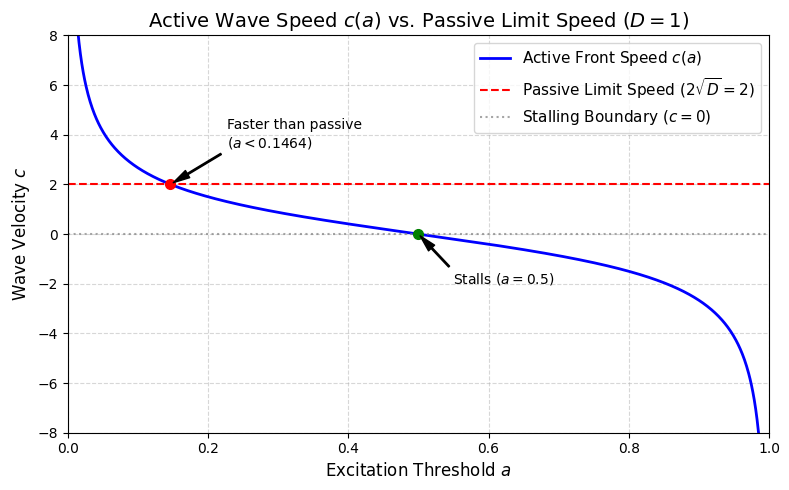

In [1]:
#Problem 1 part c
import numpy as np
import matplotlib.pyplot as plt

# Define parameter range for threshold a
a = np.linspace(0.001, 0.999, 1000)
D = 1.0

# Calculate McKean active front speed c(a)
c = np.sqrt(D) * (1 - 2 * a) / np.sqrt(a * (1 - a))

# Passive limit speed from part (a)
c_passive = 2.0 * np.sqrt(D)

# Critical crossing value where active speed equals passive limit speed
a_cross = (2 - np.sqrt(2)) / 4  # approx 0.1464

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(a, c, 'b-', linewidth=2, label=r'Active Front Speed $c(a)$')
plt.axhline(c_passive, color='r', linestyle='--', label=r'Passive Limit Speed ($2\sqrt{D} = 2$)')
plt.axhline(0, color='gray', linestyle=':', alpha=0.7, label='Stalling Boundary ($c = 0$)')

# Highlight special points
plt.plot(a_cross, c_passive, 'ro', markersize=7)
plt.annotate(f'Faster than passive\n($a < {a_cross:.4f}$)',
             xy=(a_cross, c_passive), xytext=(a_cross + 0.08, c_passive + 1.5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

plt.plot(0.5, 0, 'go', markersize=7)
plt.annotate('Stalls ($a = 0.5$)',
             xy=(0.5, 0), xytext=(0.55, -2),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

# Axis labels and formatting
plt.xlim(0, 1)
plt.ylim(-8, 8)
plt.xlabel(r'Excitation Threshold $a$', fontsize=12)
plt.ylabel(r'Wave Velocity $c$', fontsize=12)
plt.title(r'Active Wave Speed $c(a)$ vs. Passive Limit Speed ($D=1$)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

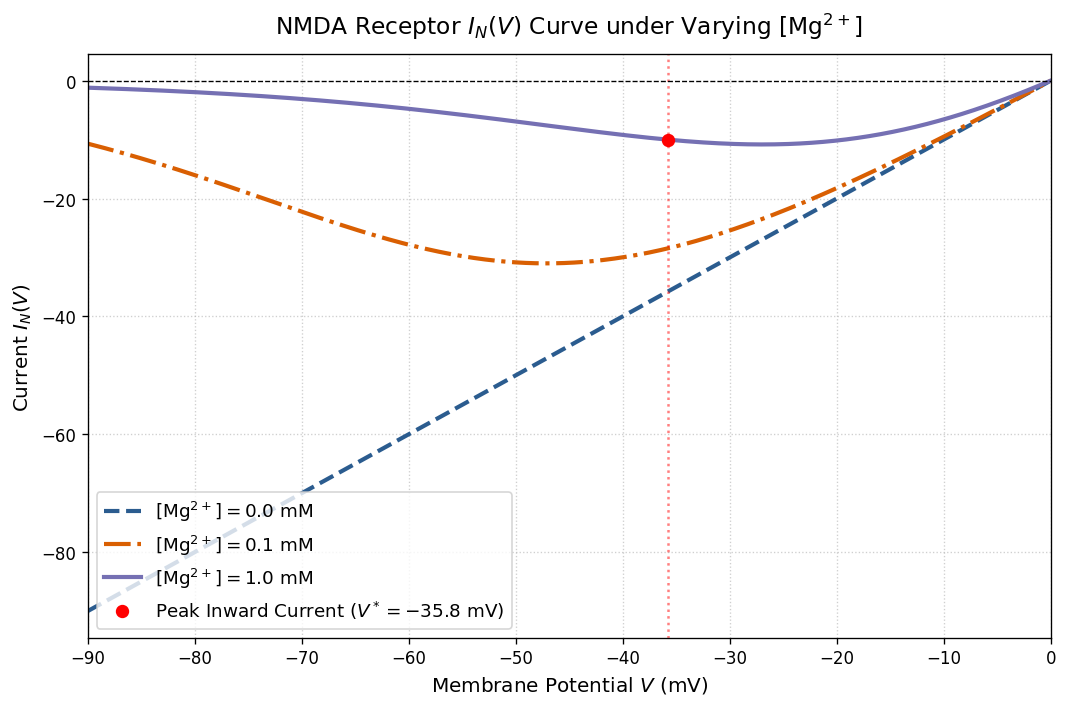

In [2]:
#Question 2 Part c
import numpy as np
import matplotlib.pyplot as plt

# --- Model Parameters ---
V0 = 16.13       # mV
EN = 0.0         # mV
g_bar = 1.0      # Normalized maximal conductance (nS or mS)
V = np.linspace(-90, 0, 500)  # Voltage range in mV

def B(V, Mg):
    """Magnesium block function B(V)."""
    if Mg == 0:
        return np.ones_like(V)
    return 1.0 / (1.0 + (Mg / 3.57) * np.exp(-V / V0))

def I_N(V, Mg):
    """NMDA current I_N(V) = g_bar * B(V) * (V - EN)."""
    return g_bar * B(V, Mg) * (V - EN)

# --- Compute Currents ---
Mg_levels = [0.0, 0.1, 1.0]
colors = ['#2b5c8f', '#d95f02', '#7570b3']
styles = ['--', '-.', '-']

plt.figure(figsize=(9, 6), dpi=120)

for Mg, color, style in zip(Mg_levels, colors, styles):
    I = I_N(V, Mg)
    plt.plot(V, I, label=f'$[\\mathrm{{Mg}}^{{2+}}] = {Mg}\\text{{ mM}}$',
             color=color, linestyle=style, linewidth=2.5)

# --- Highlight Vanishing Slope for 1.0 mM ---
V_star = -35.812  # Point where dI_N/dV = 0 for [Mg2+] = 1 mM
I_star = I_N(V_star, 1.0)

plt.plot(V_star, I_star, 'ro', markersize=7, label=f'Peak Inward Current ($V^* = {V_star:.1f}\\text{{ mV}}$)')
plt.axvline(V_star, color='red', linestyle=':', alpha=0.5)

# --- Formatting ---
plt.title(r'NMDA Receptor $I_N(V)$ Curve under Varying $[\mathrm{Mg}^{2+}]$', fontsize=14, pad=12)
plt.xlabel('Membrane Potential $V$ (mV)', fontsize=12)
plt.ylabel('Current $I_N(V)$ ', fontsize=12)
plt.xlim([-90, 0])
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='lower left')
plt.tight_layout()

# Display plot
plt.show()

<>:87: SyntaxWarning: invalid escape sequence '\s'
<>:87: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3667/2127197369.py:87: SyntaxWarning: invalid escape sequence '\s'
  ax.plot(v_axis, gaussian_pdf, 'r-', lw=2.5, label=f'Matched Gaussian\n($\sigma = {th_std:.2f}$ mV)')


nu*tau   | w (mV)   | Mean (Th/Meas)     | Var (Th/Meas)      | Skew (Th/Meas)    
--------------------------------------------------------------------------------
2        | 5.000    |  10.00 /  10.07    |  25.00 /  24.79    |  0.667 /  0.664
20       | 0.500    |  10.00 /  10.00    |   2.50 /   2.48    |  0.211 /  0.162
200      | 0.050    |  10.00 /  10.02    |   0.25 /   0.25    |  0.067 /  0.094


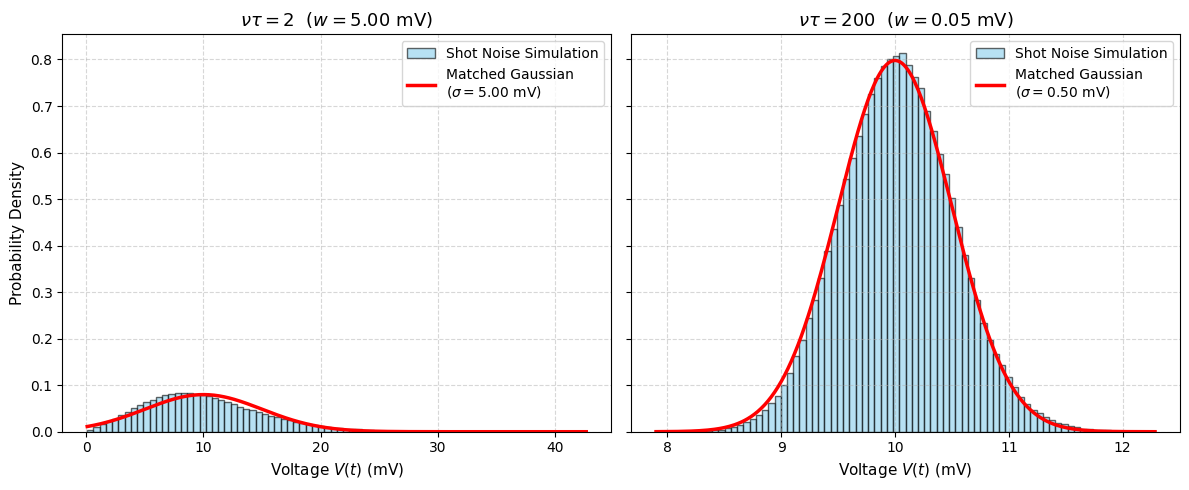

In [2]:
#Problem 4 part d
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, skew

# --- Simulation Parameters ---
tau = 0.020        # Time constant in seconds (20 ms)
V_mean_target = 10.0  # Target mean voltage in mV
T_total = 100.0    # Total simulation time in seconds
dt = 0.0001        # Integration time step (0.1 ms)
n_steps = int(T_total / dt)

# Values of nu * tau to evaluate
nu_tau_values = [2, 20, 200]

# Dictionary to store measured metrics
results = {}

# Set seed for reproducibility
np.random.seed(42)

# --- Perform Simulations ---
for nu_tau in nu_tau_values:
    nu = nu_tau / tau                   # Arrival rate (Hz)
    w = V_mean_target / nu_tau          # Synaptic weight (mV)

    # Simulate Poisson event counts per time bin
    p_event = nu * dt
    events = np.random.poisson(p_event, size=n_steps)

    # Exact Euler integration for subthreshold voltage
    V = np.zeros(n_steps)
    decay_factor = np.exp(-dt / tau)

    for t in range(1, n_steps):
        # Continuous exponential decay plus instantaneous delta jumps
        V[t] = V[t-1] * decay_factor + w * events[t]

    # Discard initial transient period (first 5 * tau) to reach stationary state
    transient_steps = int(5 * tau / dt)
    V_steady = V[transient_steps:]

    # Calculate measured sample statistics
    meas_mean = np.mean(V_steady)
    meas_var = np.var(V_steady, ddof=1)
    meas_skew = skew(V_steady)

    # Theoretical values
    theo_mean = V_mean_target
    theo_var = (nu * (w**2) * tau) / 2.0
    theo_skew = (2.0 * np.sqrt(2.0)) / (3.0 * np.sqrt(nu_tau))

    results[nu_tau] = {
        'w': w,
        'V_steady': V_steady,
        'theo': (theo_mean, theo_var, theo_skew),
        'meas': (meas_mean, meas_var, meas_skew)
    }

# --- Print Results Summary Table ---
print(f"{'nu*tau':<8} | {'w (mV)':<8} | {'Mean (Th/Meas)':<18} | {'Var (Th/Meas)':<18} | {'Skew (Th/Meas)':<18}")
print("-" * 80)
for nu_tau in nu_tau_values:
    r = results[nu_tau]
    th_m, th_v, th_s = r['theo']
    me_m, me_v, me_s = r['meas']
    print(f"{nu_tau:<8} | {r['w']:<8.3f} | {th_m:6.2f} / {me_m:6.2f}    | {th_v:6.2f} / {me_v:6.2f}    | {th_s:6.3f} / {me_s:6.3f}")

# --- Plot Histograms vs Matched Gaussians for Extreme Cases (nu*tau = 2 & 200) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)  # FIXED: sharey=True

plots_to_render = [2, 200]

for idx, nu_tau in enumerate(plots_to_render):
    ax = axes[idx]
    V_data = results[nu_tau]['V_steady']
    th_mean, th_var, _ = results[nu_tau]['theo']
    th_std = np.sqrt(th_var)

    # Plot empirical voltage histogram
    n, bins, _ = ax.hist(V_data, bins=80, density=True, alpha=0.6,
                         color='skyblue', edgecolor='black', label='Shot Noise Simulation')

    # Overlay theoretical matched Gaussian curve
    v_axis = np.linspace(bins[0], bins[-1], 300)
    gaussian_pdf = norm.pdf(v_axis, loc=th_mean, scale=th_std)
    ax.plot(v_axis, gaussian_pdf, 'r-', lw=2.5, label=f'Matched Gaussian\n($\sigma = {th_std:.2f}$ mV)')

    ax.set_title(f'$\\nu\\tau = {nu_tau}$  ($w = {results[nu_tau]["w"]:.2f}$ mV)', fontsize=13)
    ax.set_xlabel('Voltage $V(t)$ (mV)', fontsize=11)
    if idx == 0:
        ax.set_ylabel('Probability Density', fontsize=11)
    ax.legend(loc='upper right', frameon=True)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

sigma^2  | Pred Rate  | Meas Rate  | Pred P(u<0)  | Meas P(u<0) 
0.25     | 1.0000     | 0.9805     | 0.2454       | 0.2459      
1.00     | 1.0000     | 1.0042     | 0.6321       | 0.6116      
4.00     | 1.0000     | 0.9011     | 0.8848       | 0.8835      


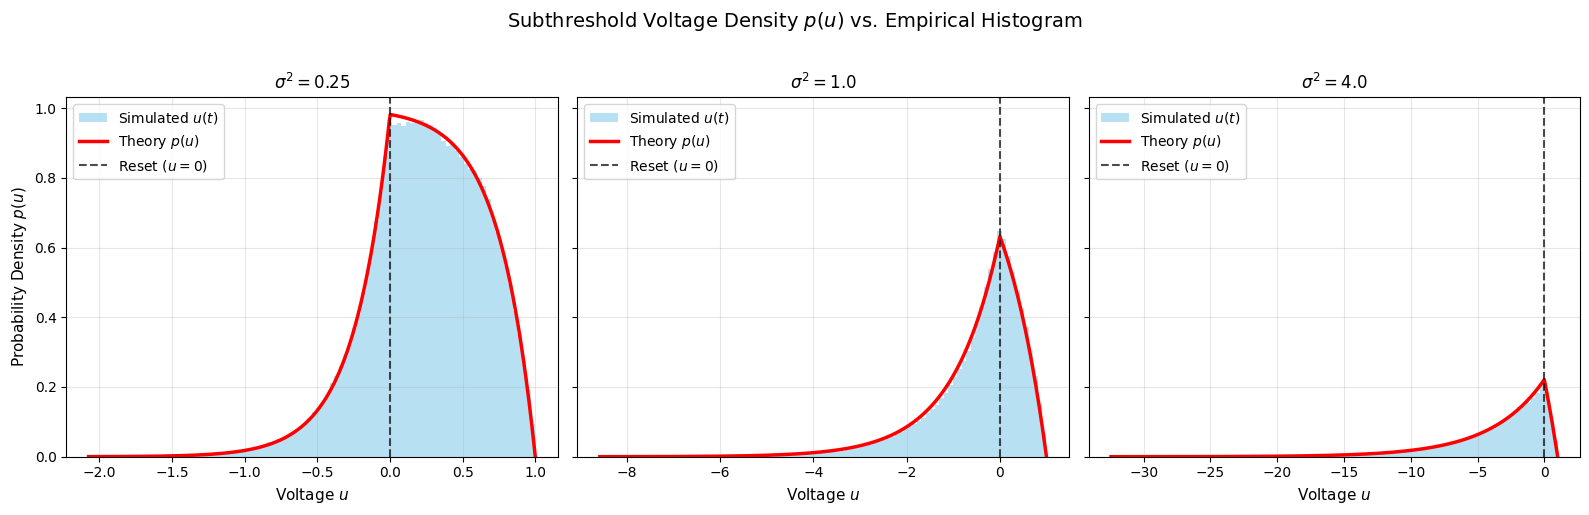

In [1]:
#Question 5 part c
import numpy as np
import matplotlib.pyplot as plt

# Force interactive inline rendering if running inside Jupyter
# %matplotlib inline

# ==========================================
# 1. PARAMETERS
# ==========================================
mu = 1.0
theta = 1.0
sigma2_values = [0.25, 1.0, 4.0]

dt = 0.0005             # Integration step size
T_total = 2000.0        # Total time
T_transient = 100.0     # Discard transient period

n_steps = int(T_total / dt)
transient_steps = int(T_transient / dt)
T_measured = T_total - T_transient

np.random.seed(42)

# ==========================================
# 2. ANALYTICAL DENSITY FUNCTION p(u)
# ==========================================
def theoretical_p(u, mu, theta, sigma2):
    nu = mu / theta
    p = np.zeros_like(u)

    # Region 0 <= u <= theta
    mask_pos = (u >= 0) & (u <= theta)
    p[mask_pos] = (nu / mu) * (1.0 - np.exp(mu * (u[mask_pos] - theta) / sigma2))

    # Region u < 0
    mask_neg = (u < 0)
    p[mask_neg] = (nu / mu) * (1.0 - np.exp(-mu * theta / sigma2)) * np.exp(mu * u[mask_neg] / sigma2)

    return p

# ==========================================
# 3. SIMULATION AND EXPLICIT PLOTTING
# ==========================================
# Create figure explicitly
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

print(f"{'sigma^2':<8} | {'Pred Rate':<10} | {'Meas Rate':<10} | {'Pred P(u<0)':<12} | {'Meas P(u<0)':<12}")
print("=" * 64)

for idx, sigma2 in enumerate(sigma2_values):
    sigma = np.sqrt(sigma2)
    sq_dt = np.sqrt(dt)

    u = 0.0
    u_history = np.zeros(n_steps - transient_steps)
    spike_count = 0
    sample_idx = 0

    # Euler-Maruyama loop
    for t in range(n_steps):
        # du = mu*dt + sqrt(2*sigma^2)*dW
        u += mu * dt + np.sqrt(2.0) * sigma * sq_dt * np.random.normal()

        if u >= theta:
            u = 0.0  # Reset
            if t >= transient_steps:
                spike_count += 1

        if t >= transient_steps:
            u_history[sample_idx] = u
            sample_idx += 1

    # Metrics
    meas_rate = spike_count / T_measured
    meas_p_neg = np.mean(u_history < 0)

    pred_rate = mu / theta
    pred_p_neg = (sigma2 / (mu * theta)) * (1.0 - np.exp(-mu * theta / sigma2))

    print(f"{sigma2:<8.2f} | {pred_rate:<10.4f} | {meas_rate:<10.4f} | {pred_p_neg:<12.4f} | {meas_p_neg:<12.4f}")

    # --- HISTOGRAM AND OVERLAY PLOT ---
    ax = axes[idx]

    # 1. Empirical voltage histogram
    ax.hist(u_history, bins=100, density=True, alpha=0.6, color='skyblue', edgecolor='none', label='Simulated $u(t)$')

    # 2. Theoretical density curve
    u_min = np.min(u_history)
    u_grid = np.linspace(u_min, theta, 500)
    p_theory = theoretical_p(u_grid, mu, theta, sigma2)

    ax.plot(u_grid, p_theory, 'r-', linewidth=2.5, label='Theory $p(u)$')

    # 3. Vertical indicator for reset level
    ax.axvline(0, color='black', linestyle='--', alpha=0.7, label='Reset ($u=0$)')

    # Formatting
    ax.set_title(f'$\\sigma^2 = {sigma2}$', fontsize=12)
    ax.set_xlabel('Voltage $u$', fontsize=11)
    if idx == 0:
        ax.set_ylabel('Probability Density $p(u)$', fontsize=11)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

plt.suptitle('Subthreshold Voltage Density $p(u)$ vs. Empirical Histogram', fontsize=14, y=1.02)
plt.tight_layout()

# EXPLICIT CALL TO DISPLAY PLOT
plt.show()